## Utilitarian Lost Insulin experiment

This notebook compares utilitarian and separately ranked utility configurations at a fixed budget and horizon. It produces result tables, planner-statistics tables, policy-selection comparisons, Pareto-front visualisations, and timing summaries.

Run the configuration and experiment cells first, then execute each analysis section in order. The policy-selection section reads every policy directly from the raw result files; the timing section uses a separate **time_df** so it does not replace the main result **df**.


In [1]:
from scripts.AbstractExperiments import ExperimentRunner
from scripts.TexTables import SaveDataFrameToTexTemplate
from copy import deepcopy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


plt.rcParams.update({
    "font.family": "Charter",
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})

def latex_config_name(name):
    return "$" + name.replace("^0", "^{0}") + "$"



## Experiment configurations

**defaultConfig** provides Budget 3 and Horizon 6. **inputConfigs** defines individual utility, act-utilitarian, separate-theory, and life/small-harm variants.

The next cell expands the mapping into **configs**, where every item contains Name, Budget, Horizon, Theories, and Considerations. Repetition counts control how many raw planner outputs are generated.


In [2]:
defaultConfig = {"Budget": 3, "Horizon": 6}
inputConfigs = {
    "(h)": {"Theories": [["Hal", "Utility", 0]], "Considerations": [["Hal", "Hal"]]},
    "(c)": {"Theories": [["Carla", "Utility", 0]], "Considerations": [["Carla", "Carla"]]},
    "(au)": {"Theories": [["AU", "Utility", 0]], "Considerations": [["Overall", "AU"]]},
    "(h, c)": {"Theories": [["AU", "Utility", 0]], "Considerations": [["Hal", "AU"], ["Carla", "AU"]]},
    "(h)^0, (c)^0": {"Theories": [["Carla", "Utility", 0], ["Hal", "Utility", 0]], "Considerations": [["Carla", "Carla"], ["Hal", "Hal"]]},
    "(h)^0, (c)^0, (h,c)^0": {"Theories": [["Carla", "Utility", 0], ["Hal", "Utility", 0], ["AU", "Utility", 0]], "Considerations": [["Carla",["AU", "Carla"]], ["Hal", ["AU", "Hal"]]]},

    "(hl)^0, (cl)^0": {"Theories": [["HalLife", "Utility", 0], ["CarlaLife", "Utility", 0]],
                    "Considerations": [["CarlaLife", "CarlaLife"], ["HalLife", "HalLife"]]
    },
    "(hl)^0, (cl)^0, (hs)^1, (cs)^1": {
        "Theories": [["HalLife", "Utility", 0], ["CarlaLife", "Utility", 0], ["Hal", "Utility", 1], ["Carla", "Utility", 1]],
        "Considerations": [["CarlaLife", "CarlaLife"], ["HalLife", "HalLife"], ["Carla", "Carla"], ["Hal", "Hal"]]
    }
}
Config_repetitions=1
Environment_repetitions = 10

In [3]:
configs = []
for name, dat in inputConfigs.items():
    c = deepcopy(defaultConfig)
    c["Name"] = name
    c["Theories"] = dat["Theories"]
    c["Considerations"] = dat["Considerations"]
    c["Budget"] = dat["Budget"] if "Budget" in dat.keys() else c["Budget"]
    c["Horizon"] = dat["Horizon"] if "Horizon" in dat.keys() else c["Horizon"]
    configs.append(c)

## Build, run, and extract

**er** stores outputs under UtilitarianExp. This cell builds environments, invokes the planner for every repetition, and extracts planner fields into **er.data**.

This is the expensive stage. Existing valid raw outputs can be analysed without rerunning the planner.


In [4]:
er = ExperimentRunner("LostInsulin", configs, MoralPlanner_Location="/../../",outFolder="UtilitarianExp")

In [6]:
er.buildEnvironments(configRepetitions=Config_repetitions)
er.runPlanner(configRepetitions=Config_repetitions, envRepetitions=Environment_repetitions)

Written LostInsulin MMMDP with 689 states and theories [{'Name': 'Hal', 'Type': 'Utility', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/LostInsulin/../../Data/Experiments/LostInsulin/UtilitarianExp/mdps/(h)_con0.json

Written LostInsulin MMMDP with 689 states and theories [{'Name': 'Carla', 'Type': 'Utility', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/LostInsulin/../../Data/Experiments/LostInsulin/UtilitarianExp/mdps/(c)_con0.json

Written LostInsulin MMMDP with 689 states and theories [{'Name': 'AU', 'Type': 'Utility', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/LostInsulin/../../Data/Experiments/LostInsulin/UtilitarianExp/mdps/(au)_con0.json

Written LostInsulin MMMDP with 689 states and theories [{'Name': 'AU', 'Type': 'Utility', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/LostInsulin/../../Data/Experiments/LostInsulin/UtilitarianExp/mdps/(h, c)_con0.json

Written LostInsulin MMMDP with 689 state

In [5]:
er.extractData(configRepetitions=Config_repetitions, envRepetitions=Environment_repetitions)

## Outcome and planner-result tables

The main DataFrames are:

| DataFrame | Contents |
|---|---|
| **df** | One row per extracted repetition, including utilities, non-acceptability, policy counts, search statistics, and timing |
| **df_moral** | One aggregated outcome row per configuration |
| **df_stat** | Expanded states, average backups, iterations, and total runtime per configuration |

The cleaning step combines Hal/Carla and HalLife/CarlaLife fields into common utility columns and shortens labels before exporting TeX tables.


In [6]:
cols = ["Config_name", 'Hal_Utility', 'Carla_Utility', "Min_non_accept", "Num_of_min_non_accept", "Num_of_sols", "Total_time"]
df = pd.DataFrame(er.data)

df = df.replace(["", "N/A", "NA", "nan", "None"], np.nan)

df['Carla_Utility'] = df['Carla']
if 'Carla' in df.columns and 'CarlaLife' in df.columns:
    df['Carla_Utility'] = df['Carla'].combine_first(df['CarlaLife'])

df['Hal_Utility'] = df['Hal']
if 'Hal' in df.columns and 'HalLife' in df.columns:
    df['Hal_Utility'] = df['Hal'].combine_first(df['HalLife'])

if 'Overall' in df.columns:
    df['Hal_Utility'] = df['Hal_Utility'].combine_first(df['Overall'])

df['Hal_Utility'] = pd.to_numeric(df['Hal_Utility'])
df['Carla_Utility'] = pd.to_numeric(df['Carla_Utility'])
df['Hal_Utility'] = df['Hal_Utility'].round(3)
df['Carla_Utility'] = df['Carla_Utility'].round(3)
df['Min_non_accept'] = df['Min_non_accept'].round(3)

df = df.replace(np.nan, "SKIP")

agg_rules = {
            'Hal_Utility': 'first',
            'Carla_Utility': 'first',
            "Num_of_min_non_accept": 'first',
            "Num_of_sols": 'first',
            "Min_non_accept": 'first',
            'Total_time': 'mean',
        }
        

df_moral = df[cols].groupby('Config_name', sort=False).agg(agg_rules)

SaveDataFrameToTexTemplate(df_moral, f"{er.texTablesFolder}/UtilitarianResults.tex", f"{er.texOutFolder}/Utility_table.tex", row_template_mode=False,timestamp=er.datetimeNow)
df_moral.head(10)

Successfully saved populated LaTeX to /home/psiko/Programming/MoralPlanner/Notebooks/LostInsulin/../../Data/Experiments/LostInsulin/UtilitarianExp/tex/Utility_table.tex


,Hal_Utility,Carla_Utility,Num_of_min_non_accept,Num_of_sols,Min_non_accept,Total_time
Config_name,,,,,,
(h),-55.27,SKIP,1,1,0.000,345.4
(c),SKIP,0.0,1,1,0.000,1158.3
(au),-64.59,SKIP,1,1,0.000,316.3
"(h, c)",-62.776,-1.814,1,16,0.000,5984.6
"(h)^0, (c)^0",-55.27,-24.986,1,16,0.544,5925.4
"(h)^0, (c)^0, (h,c)^0",-62.776,-1.814,1,16,0.646,6004.6
"(hl)^0, (cl)^0",-45.902,-22.114,1,54,0.221,36320.8
"(hl)^0, (cl)^0, (hs)^1, (cs)^1",-55.902,-39.105,1,72,0.221,50893.5


In [7]:
agg_rules = {
    "Expanded_states": "first",
    "Backups": "mean",
    "Iterations": "mean",
    "Total_time": "mean",
}

columns = [
    "Config_name",
    "Expanded_states",
    "Backups",
    "Iterations",
    "Total_time",   
]

df_stat = (
    df[columns]
    .groupby("Config_name", sort=False, as_index=False)
    .agg(agg_rules)
)

SaveDataFrameToTexTemplate(
    df_stat,
    f"{er.texTablesFolder}/PlanResults.tex",
    f"{er.texOutFolder}/Plan_table.tex",
    row_template_mode=True,
    timestamp=er.datetimeNow,
)

df_stat.head(10)

Successfully saved populated LaTeX to /home/psiko/Programming/MoralPlanner/Notebooks/LostInsulin/../../Data/Experiments/LostInsulin/UtilitarianExp/tex/Plan_table.tex


,Config_name,Expanded_states,Backups,Iterations,Total_time
0,(h),42,135.0,8.0,345.4
1,(c),82,255.0,8.0,1158.3
2,(au),38,117.0,8.0,316.3
3,"(h, c)",390,1944.0,11.0,5984.6
4,"(h)^0, (c)^0",390,1944.0,11.0,5925.4
5,"(h)^0, (c)^0, (h,c)^0",390,1944.0,11.0,6004.6
6,"(hl)^0, (cl)^0",618,4409.0,14.0,36320.8
7,"(hl)^0, (cl)^0, (hs)^1, (cs)^1",609,4388.0,14.0,50893.5


## Compare policy-selection rules

The existing **er.GetWorthData** helper only returns policies tied for minimum total non-acceptability. 

The next cells read every policy listed in **Solutions_Order** from each raw result file and build **policy_df**. It contains:

| Column group | Contents |
|---|---|
| Run identifiers | Config_name, Conf_rep, Env_rep, Horizon |
| Policy identifiers | Policy_order and Solution_index |
| Overall score | Total_NACC, taken from the policy Acceptability field |
| Theory scores | One nacc_THEORY column per moral theory |
| Outcomes | All expectation fields stored for the policy, plus canonical Hal_wellbeing and Carla_wellbeing |

Selection happens separately inside each configuration/repetition. The selected outcomes are then averaged, producing one row per configuration and acceptability method.

The implemented methods are:

- **Minimum total NACC:** the existing rule.
- **Fair NACC:** minimise the range between theory-specific non-acceptabilities.
- **Minimax NACC:** minimise the largest theory-specific non-acceptability, protecting the worst-scoring theory.
- **Maximise lowest theory NACC:** the literal maximin-style rule suggested for comparison. Because lower non-acceptability is normally better, this rule may behave counter-intuitively.
- **Weighted NACC:** minimise a weighted average of theory-specific non-acceptabilities.

Ties are resolved by lower total NACC, then lower worst-theory NACC, then original policy order. For configurations with only one theory, the theory range is always zero, so Fair NACC falls back to those tie-breakers.


**policy_nacc_table** is the explicit per-solution view. It places Total_NACC and every available nacc_THEORY column beside Hal_wellbeing and Carla_wellbeing. A theory column is NaN when that theory is not part of the configuration.

Use **show_policy_nacc(config_name=..., env_rep=...)** to inspect a manageable subset. The underlying table always retains every loaded solution.


In [14]:
def combine_first_numeric(data, candidate_columns):
    """Combine alternative names for the same outcome into one numeric Series."""
    combined = pd.Series(np.nan, index=data.index, dtype=float)

    for column in candidate_columns:
        if column in data.columns:
            combined = combined.combine_first(
                pd.to_numeric(data[column], errors="coerce")
            )

    return combined


policy_df = er.load_all_policy_data(config_repetitions=Config_repetitions, environment_repetitions=Environment_repetitions )

policy_df["Total_NACC"] = pd.to_numeric(
    policy_df["Total_NACC"],
    errors="coerce",
)

# Match the wellbeing conventions used in the earlier result table.
policy_df["Hal_wellbeing"] = combine_first_numeric(
    policy_df,
    ["Hal", "HalLife", "Overall"],
)
policy_df["Carla_wellbeing"] = combine_first_numeric(
    policy_df,
    ["Carla", "CarlaLife"],
)

theory_nacc_columns = [column for column in policy_df.columns if column.startswith("nacc_") ]

if not theory_nacc_columns:
    raise ValueError(
        "No nacc_THEORY columns were found in the raw policy data."
    )

policy_df[theory_nacc_columns] = policy_df[theory_nacc_columns].apply(pd.to_numeric, errors="coerce")

policy_df = policy_df.drop(policy_df[policy_df['Config_name'].isin(['(h)', '(c)', '(h, c)', '(au)'])].index)
# Put the theory-specific values next to the selected policy outcomes.
policy_nacc_table_columns = [
    column
    for column in [
        "Config_name",
        "Conf_rep",
        "Env_rep",
        "Horizon",
        "Policy_order",
        "Solution_index",
        "Hal_wellbeing",
        "Carla_wellbeing",
        "Total_NACC",
    ]
    if column in policy_df.columns
] + theory_nacc_columns

policy_nacc_table = (
    policy_df[policy_nacc_table_columns]
    .sort_values(
        [
            "Config_name",
            "Conf_rep",
            "Env_rep",
            "Policy_order",
        ]
    )
    .reset_index(drop=True)
)


def show_policy_nacc(
    config_name=None,
    conf_rep=None,
    env_rep=None,
    max_rows=None,
):
    """Filter the policy/theory table without changing policy_nacc_table."""
    table = policy_nacc_table

    filters = {
        "Config_name": config_name,
        "Conf_rep": conf_rep,
        "Env_rep": env_rep,
    }
    for column, value in filters.items():
        if value is not None:
            table = table[table[column] == value]

    if max_rows is not None:
        table = table.head(max_rows)

    return table


# Examples:
# show_policy_nacc(config_name="(h)^0, (c)^0", env_rep=0)
# show_policy_nacc(config_name="(hl)^0, (cl)^0", max_rows=20)
show_policy_nacc()



,Config_name,Conf_rep,Env_rep,Horizon,Policy_order,Solution_index,Hal_wellbeing,Carla_wellbeing,Total_NACC,nacc_Hal,nacc_Carla,nacc_AU,nacc_HalLife,nacc_CarlaLife
0,"(h)^0, (c)^0",0,0,7,0,0,-55.2698,-24.9865,0.543668,0.000000,0.543668,NaN,NaN,NaN
1,"(h)^0, (c)^0",0,0,7,1,5,-62.7758,-1.8143,0.645902,0.627758,0.018143,NaN,NaN,NaN
2,"(h)^0, (c)^0",0,0,7,2,6,-59.3862,-5.9691,0.653553,0.593862,0.059691,NaN,NaN,NaN
3,"(h)^0, (c)^0",0,0,7,3,11,-66.8884,-0.4906,0.673791,0.668884,0.004906,NaN,NaN,NaN
4,"(h)^0, (c)^0",0,0,7,4,2,-67.9281,-0.3925,0.683206,0.679281,0.003925,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1575,"(hl)^0, (cl)^0, (hs)^1, (cs)^1",0,9,7,67,32,-67.9281,-0.3925,1.362488,0.679281,0.000000,NaN,0.679281,0.003925
1576,"(hl)^0, (cl)^0, (hs)^1, (cs)^1",0,9,7,68,70,-69.2539,-0.1642,1.385429,0.692970,0.000000,NaN,0.692326,0.000133
1577,"(hl)^0, (cl)^0, (hs)^1, (cs)^1",0,9,7,69,28,-69.2696,-0.1472,1.385526,0.692696,0.000000,NaN,0.692696,0.000133
1578,"(hl)^0, (cl)^0, (hs)^1, (cs)^1",0,9,7,70,34,-69.3696,-0.1509,1.387610,0.694127,0.000000,NaN,0.693483,0.000000


In [15]:
# Increase a value to make that theory more important.
# Unlisted theories receive weight 1.0. A weight of 0 ignores a theory.
THEORY_WEIGHTS = {
     "Hal": 1.0,
     "Carla": 2.0,
     "AU": 3.0,
}


def weighted_nacc(row, nacc_columns, theory_weights):
    values = []
    weights = []

    for column in nacc_columns:
        value = row[column]
        theory_name = column.removeprefix("nacc_")
        weight = float(theory_weights.get(theory_name, 1.0))

        if weight < 0:
            raise ValueError(
                f"Theory weight must be non-negative: {theory_name}={weight}"
            )
        if pd.notna(value) and weight > 0:
            values.append(float(value))
            weights.append(weight)

    if not values:
        return np.nan

    return np.average(values, weights=weights)


policy_scores_df = policy_df.copy()

# These row-wise scores only use theories present in that configuration.
policy_scores_df["Theory_NACC_minimum"] = (
    policy_scores_df[theory_nacc_columns].min(axis=1, skipna=True)
)
policy_scores_df["Theory_NACC_maximum"] = (
    policy_scores_df[theory_nacc_columns].max(axis=1, skipna=True)
)
policy_scores_df["Theory_NACC_range"] = (
    policy_scores_df["Theory_NACC_maximum"]
    - policy_scores_df["Theory_NACC_minimum"]
)
policy_scores_df["Weighted_NACC"] = policy_scores_df.apply(
    weighted_nacc,
    axis=1,
    nacc_columns=theory_nacc_columns,
    theory_weights=THEORY_WEIGHTS,
)

policy_scores_df.head()


,Config_name,Conf_rep,Env_rep,Horizon,Policy_order,Solution_index,Total_NACC,nacc_Hal,Hal,nacc_Carla,...,nacc_HalLife,nacc_CarlaLife,CarlaLife,HalLife,Hal_wellbeing,Carla_wellbeing,Theory_NACC_minimum,Theory_NACC_maximum,Theory_NACC_range,Weighted_NACC
190,"(h)^0, (c)^0",0,0,7,0,0,0.543668,0.000000,-55.2698,0.543668,...,NaN,NaN,NaN,NaN,-55.2698,-24.9865,0.000000,0.543668,0.543668,0.362445
191,"(h)^0, (c)^0",0,0,7,1,5,0.645902,0.627758,-62.7758,0.018143,...,NaN,NaN,NaN,NaN,-62.7758,-1.8143,0.018143,0.627758,0.609615,0.221348
192,"(h)^0, (c)^0",0,0,7,2,6,0.653553,0.593862,-59.3862,0.059691,...,NaN,NaN,NaN,NaN,-59.3862,-5.9691,0.059691,0.593862,0.534170,0.237748
193,"(h)^0, (c)^0",0,0,7,3,11,0.673791,0.668884,-66.8884,0.004906,...,NaN,NaN,NaN,NaN,-66.8884,-0.4906,0.004906,0.668884,0.663978,0.226232
194,"(h)^0, (c)^0",0,0,7,4,2,0.683206,0.679281,-67.9281,0.003925,...,NaN,NaN,NaN,NaN,-67.9281,-0.3925,0.003925,0.679281,0.675356,0.229044


In [17]:
ACCEPTABILITY_METHODS = {
    "Minimum total NACC": {
        "score_column": "Total_NACC",
        "ascending": True,
    },
    "Fair NACC (smallest theory range)": {
        "score_column": "Theory_NACC_range",
        "ascending": True,
    },
    "Minimax NACC (smallest worst theory)": {
        "score_column": "Theory_NACC_maximum",
        "ascending": True,
    },
    "Maximise lowest theory NACC": {
        "score_column": "Theory_NACC_minimum",
        "ascending": False,
    },
    "Weighted NACC": {
        "score_column": "Weighted_NACC",
        "ascending": True,
    },
}


def select_policy(run_policies, score_column, ascending):
    """Select one policy with deterministic, welfare-neutral tie-breakers."""
    candidates = run_policies.dropna(subset=[score_column]).copy()
    if candidates.empty:
        return None

    sort_columns = [score_column]
    sort_ascending = [ascending]

    # Lower total/worst NACC resolves score ties. Policy_order makes the
    # remaining tie deterministic without using Hal or Carla wellbeing.
    for tie_column in [ "Total_NACC", "Theory_NACC_maximum", "Policy_order"]:
        if tie_column not in sort_columns:
            sort_columns.append(tie_column)
            sort_ascending.append(True)

    return candidates.sort_values(sort_columns, ascending=sort_ascending, kind="mergesort").iloc[0]


run_identifier_columns = [
    "Config_name",
    "Conf_rep",
    "Env_rep",
]
selected_records = []

for run_identifiers, run_policies in policy_scores_df.groupby(
    run_identifier_columns,
    sort=False,
    dropna=False,
):
    config_name, conf_rep, env_rep = run_identifiers

    for method_name, method in ACCEPTABILITY_METHODS.items():
        selected_policy = select_policy(
            run_policies,
            score_column=method["score_column"],
            ascending=method["ascending"],
        )
        if selected_policy is None:
            continue

        selected_records.append({
            "Config_name": config_name,
            "Acceptability_method": method_name,
            "Conf_rep": conf_rep,
            "Env_rep": env_rep,
            "Policy_order": selected_policy["Policy_order"],
            "Solution_index": selected_policy["Solution_index"],
            "Hal_wellbeing": selected_policy["Hal_wellbeing"],
            "Carla_wellbeing": selected_policy["Carla_wellbeing"],
            "Total_NACC": selected_policy["Total_NACC"],
            "Theory_NACC_range": selected_policy["Theory_NACC_range"],
            "Theory_NACC_maximum": selected_policy[
                "Theory_NACC_maximum"
            ],
            "Weighted_NACC": selected_policy["Weighted_NACC"],
        })

selected_policy_df = pd.DataFrame(selected_records)

policy_selection_table = (
    selected_policy_df
    .groupby(
        ["Config_name", "Acceptability_method"],
        sort=False,
        as_index=False,
    )
    .agg(
        Hal_wellbeing=("Hal_wellbeing", "mean"),
        Carla_wellbeing=("Carla_wellbeing", "mean"),
        Selected_total_NACC=("Total_NACC", "mean"),
        Selected_theory_range=("Theory_NACC_range", "mean"),
        Selected_worst_theory_NACC=(
            "Theory_NACC_maximum",
            "mean",
        ),
        Selected_weighted_NACC=("Weighted_NACC", "mean"),
        Number_of_runs=("Env_rep", "size"),
    )
)

configuration_order = [config["Name"] for config in configs]
method_order = list(ACCEPTABILITY_METHODS)

policy_selection_table["Config_name"] = pd.Categorical(
    policy_selection_table["Config_name"],
    categories=configuration_order,
    ordered=True,
)
policy_selection_table["Acceptability_method"] = pd.Categorical(
    policy_selection_table["Acceptability_method"],
    categories=method_order,
    ordered=True,
)
policy_selection_table = (
    policy_selection_table
    .sort_values(["Config_name", "Acceptability_method"])
    .reset_index(drop=True)
)

# A compact view matching the earlier Hal/Carla outcome table.
wellbeing_selection_table = policy_selection_table[
    [
        "Config_name",
        "Acceptability_method",
        "Hal_wellbeing",
        "Carla_wellbeing",
        "Number_of_runs",
    ]
].copy()

wellbeing_selection_table.round(3)



,Config_name,Acceptability_method,Hal_wellbeing,Carla_wellbeing,Number_of_runs
0,"(h)^0, (c)^0",Minimum total NACC,-55.270,-24.986,10
1,"(h)^0, (c)^0",Fair NACC (smallest theory range),-57.512,-18.012,10
2,"(h)^0, (c)^0",Minimax NACC (smallest worst theory),-55.270,-24.986,10
3,"(h)^0, (c)^0",Maximise lowest theory NACC,-57.512,-18.012,10
4,"(h)^0, (c)^0",Weighted NACC,-62.776,-1.814,10
5,"(h)^0, (c)^0, (h,c)^0",Minimum total NACC,-62.776,-1.814,10
6,"(h)^0, (c)^0, (h,c)^0",Fair NACC (smallest theory range),-57.512,-18.012,10
7,"(h)^0, (c)^0, (h,c)^0",Minimax NACC (smallest worst theory),-62.776,-1.814,10
8,"(h)^0, (c)^0, (h,c)^0",Maximise lowest theory NACC,-57.512,-18.012,10
9,"(h)^0, (c)^0, (h,c)^0",Weighted NACC,-62.776,-1.814,10


## Reachable policies and states

**df_** is a narrow view of **er.data** containing Config_name, Horizon, Total_reachable_policies, and Total_states.

The consistency check verifies that repetitions agree for each configuration/horizon pair. Consistent data is deduplicated and pivoted into **result**; inconsistent rows are printed for diagnosis.


In [11]:
df_ = pd.DataFrame(er.data)[
    [
        "Config_name",
        "Horizon",
        "Total_reachable_policies",
        "Total_states",
    ]
].copy()

value_columns = [
    "Total_reachable_policies",
    "Total_states",
]

# Check whether each Config_name/Horizon pair always has one value
# for both Total_reachable_policies and Total_states.
value_counts = (
    df_
    .groupby(
        ["Config_name", "Horizon"],
        dropna=False,
    )[value_columns]
    .nunique(dropna=False)
)

all_pairs_consistent = value_counts.le(1).all().all()

if not all_pairs_consistent:
    # Keep any Config_name/Horizon pair where at least one measured
    # column has multiple values.
    inconsistent_pairs = value_counts[
        value_counts.gt(1).any(axis=1)
    ]

    print("The following key pairs have multiple values:")
    print(inconsistent_pairs)

    inconsistent_rows = (
        df_
        .merge(
            inconsistent_pairs.index.to_frame(index=False),
            on=["Config_name", "Horizon"],
            how="inner",
        )
        .sort_values(
            ["Config_name", "Horizon"] + value_columns
        )
    )

    print("\nUnderlying inconsistent rows:")
    print(inconsistent_rows)

else:
    result = (
        df_
        .drop_duplicates(
            subset=[
                "Config_name",
                "Horizon",
                *value_columns,
            ]
        )
        .pivot(
            index="Config_name",
            columns="Horizon",
            values=value_columns,
        )
        .sort_index()
        .sort_index(axis=1)
    )

    print(result)

                               Total_reachable_policies Total_states
Horizon                                               6            6
Config_name                                                         
(au)                                             507068          689
(c)                                              507068          689
(h)                                              507068          689
(h)^0, (c)^0                                     507068          689
(h)^0, (c)^0, (h,c)^0                            507068          689
(h, c)                                           507068          689
(hl)^0, (cl)^0                                   507068          689
(hl)^0, (cl)^0, (hs)^1, (cs)^1                   507068          689


## Pareto coverage set

This section reads complete solution objects directly from raw planner JSON.

**configuration_data** is a list of plotting records rather than a DataFrame. Each record stores cumulative policy index, non-acceptability, and the Hal-minus-Carla expectation difference. Line style identifies configuration and colour shows relative favouring.


/tmp/ipykernel_78580/3872848619.py:334: UserWarning: Glyph 8592 (\N{LEFTWARDS ARROW}) missing from font(s) Charter.
  fig.tight_layout()
/tmp/ipykernel_78580/3872848619.py:334: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Charter.
  fig.tight_layout()
/tmp/ipykernel_78580/3872848619.py:336: UserWarning: Glyph 8592 (\N{LEFTWARDS ARROW}) missing from font(s) Charter.
  fig.savefig(
/tmp/ipykernel_78580/3872848619.py:336: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Charter.
  fig.savefig(
/home/psiko/miniconda3/envs/MoralPlanner/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8592 (\N{LEFTWARDS ARROW}) missing from font(s) Charter.
  fig.canvas.print_figure(bytes_io, **kw)
/home/psiko/miniconda3/envs/MoralPlanner/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Charter.
  fig.canvas.print_figure(bytes_io, **kw)


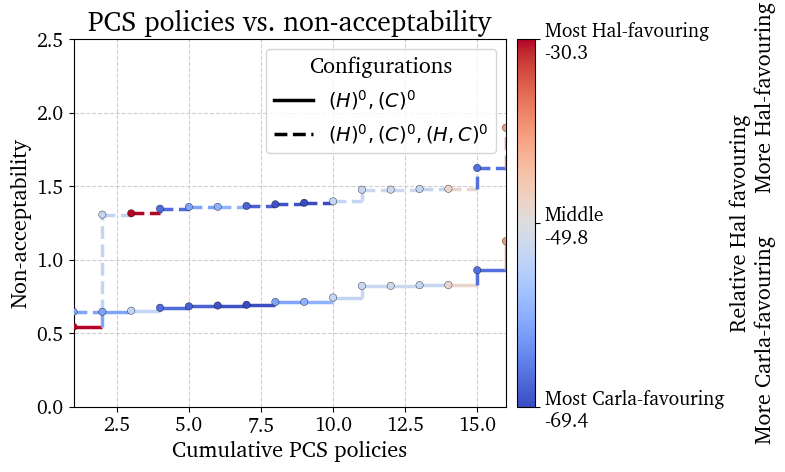

In [12]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D


fig, ax = plt.subplots(figsize=(8, 5))

config_names = [
    "(Hal)^0, (Carla)^0",
    "(Hal)^0, (Carla)^0, (Hal,Carla)^0",
]

# Configuration is represented by line style.
config_linestyles = {
    config_names[0]: "solid",
    config_names[1]: "dashed",
}


def numeric_value(solution, *keys):
    """Extract a nested JSON value and convert it to float."""
    value = solution

    for key in keys:
        value = value[key]

    try:
        return float(value)
    except (TypeError, ValueError) as error:
        key_path = " -> ".join(keys)

        raise ValueError(
            f"Expected a numeric value at {key_path}, "
            f"but found {value!r}"
        ) from error


configuration_data = []

for config_name in config_names:
    out_file = er.makePlanOutFileName(
        config_name,
        0,
        0,
    )

    with open(out_file, "r") as file:
        json_data = json.load(file)

    solutions = json_data["Solutions"]

    # Sort complete solution objects so that the expectations remain
    # associated with their corresponding non-acceptability values.
    sorted_solutions = sorted(
        solutions,
        key=lambda solution: numeric_value(
            solution,
            "Acceptability",
        ),
    )

    non_acceptability = np.asarray(
        [
            numeric_value(
                solution,
                "Acceptability",
            )
            for solution in sorted_solutions
        ],
        dtype=float,
    )

    hal_minus_carla = np.asarray(
        [
            numeric_value(
                solution,
                "Expectation",
                "Hal",
            )
            - numeric_value(
                solution,
                "Expectation",
                "Carla",
            )
            for solution in sorted_solutions
        ],
        dtype=float,
    )

    cumulative_policies = np.arange(
        1,
        len(sorted_solutions) + 1,
    )

    configuration_data.append(
        {
            "name": config_name,
            "x": cumulative_policies,
            "y": non_acceptability,
            "difference": hal_minus_carla,
        }
    )


# Combine differences from every configuration so that all plotted policies
# use the same relative colour scale.
all_differences = np.concatenate(
    [
        data["difference"]
        for data in configuration_data
    ]
)

minimum_difference = np.min(all_differences)
maximum_difference = np.max(all_differences)

# Normalise relative to the observed dataset:
#
# minimum difference -> blue
# middle of range    -> white
# maximum difference -> red
#
# This works even when every policy has Hal - Carla < 0.
if np.isclose(minimum_difference, maximum_difference):
    # All policies have effectively the same difference. Expand the range
    # slightly to avoid an invalid normalisation.
    padding = max(
        abs(minimum_difference) * 0.01,
        1e-9,
    )

    minimum_colour_value = minimum_difference - padding
    maximum_colour_value = maximum_difference + padding
    midpoint = minimum_difference
else:
    minimum_colour_value = minimum_difference
    maximum_colour_value = maximum_difference
    midpoint = (
        minimum_difference
        + maximum_difference
    ) / 2.0

normalisation = mcolors.TwoSlopeNorm(
    vmin=minimum_colour_value,
    vcenter=midpoint,
    vmax=maximum_colour_value,
)

# Blue = relatively more favourable to Carla.
# Red = relatively more favourable to Hal.
colour_map = plt.get_cmap("coolwarm")


def make_step_segments(x, y, values):
    """
    Construct a post-style step plot as separately colourable segments.

    Each horizontal section uses the Hal-Carla difference belonging to the
    solution at that non-acceptability level.
    """
    segments = []
    segment_values = []

    if len(x) == 1:
        segments.append(
            [
                (x[0] - 0.15, y[0]),
                (x[0] + 0.15, y[0]),
            ]
        )

        segment_values.append(values[0])

        return (
            np.asarray(segments),
            np.asarray(segment_values),
        )

    for index in range(len(x) - 1):
        # Horizontal part of the post-style step.
        segments.append(
            [
                (x[index], y[index]),
                (x[index + 1], y[index]),
            ]
        )

        segment_values.append(values[index])

        # Vertical transition to the next policy.
        segments.append(
            [
                (x[index + 1], y[index]),
                (x[index + 1], y[index + 1]),
            ]
        )

        # Colour the transition using the policy reached.
        segment_values.append(values[index + 1])

    return (
        np.asarray(segments),
        np.asarray(segment_values),
    )


for data in configuration_data:
    segments, segment_values = make_step_segments(
        data["x"],
        data["y"],
        data["difference"],
    )

    line_collection = LineCollection(
        segments,
        cmap=colour_map,
        norm=normalisation,
        linewidth=2.5,
        linestyles=config_linestyles[data["name"]],
    )

    line_collection.set_array(segment_values)
    ax.add_collection(line_collection)

    # Points make the colour associated with each individual policy clearer.
    ax.scatter(
        data["x"],
        data["y"],
        c=data["difference"],
        cmap=colour_map,
        norm=normalisation,
        s=28,
        edgecolors="black",
        linewidths=0.25,
        zorder=3,
    )


ax.set_title("PCS policies vs. non-acceptability")

ax.set_ylabel("Non-acceptability")
ax.set_xlabel("Cumulative PCS policies")

ax.grid(
    True,
    linestyle="--",
    alpha=0.6,
)

ax.set_ylim(
    bottom=0,
    top=2.5,
)

maximum_policy_count = max(
    data["x"][-1]
    for data in configuration_data
)

ax.set_xlim(
    left=1,
    right=maximum_policy_count,
)


# Create a line-style legend for the two configurations.
configuration_legend_handles = []

for config_name in config_names:
    formatted_name = (
        config_name
        .replace("Hal", "H")
        .replace("Carla", "C")
    )

    configuration_legend_handles.append(
        Line2D(
            [0],
            [0],
            color="black",
            linewidth=2.5,
            linestyle=config_linestyles[config_name],
            label=latex_config_name(formatted_name),
        )
    )

ax.legend(
    handles=configuration_legend_handles,
    title="Configurations",
)


# Shared relative colour scale.
scalar_mappable = plt.cm.ScalarMappable(
    norm=normalisation,
    cmap=colour_map,
)

scalar_mappable.set_array([])

colour_bar = fig.colorbar(
    scalar_mappable,
    ax=ax,
    pad=0.02,
)

colour_bar.set_label(
    "Relative Hal favouring\n"
    "More Carla-favouring ←   → More Hal-favouring"
)

# Label the endpoints with the observed numerical differences.
colour_bar.set_ticks(
    [
        minimum_difference,
        midpoint,
        maximum_difference,
    ]
)

colour_bar.set_ticklabels(
    [
        f"Most Carla-favouring\n{minimum_difference:.3g}",
        f"Middle\n{midpoint:.3g}",
        f"Most Hal-favouring\n{maximum_difference:.3g}",
    ]
)


fig.tight_layout()

fig.savefig(
    f"{er.figuresFolder}/Solution_Growth.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## Timing-component summary

This section reads raw duration fields into **time_df**, with Config_name, Env_rep, Heuristic, Plan, Solution and Trajectory Extraction, MEHR, and Total.

**averages** is the mean of those timing categories by configuration and feeds the grouped bar chart. The main result **df** from the outcome-table section remains available for analyses that use Total_time, Horizon, or other planner columns.


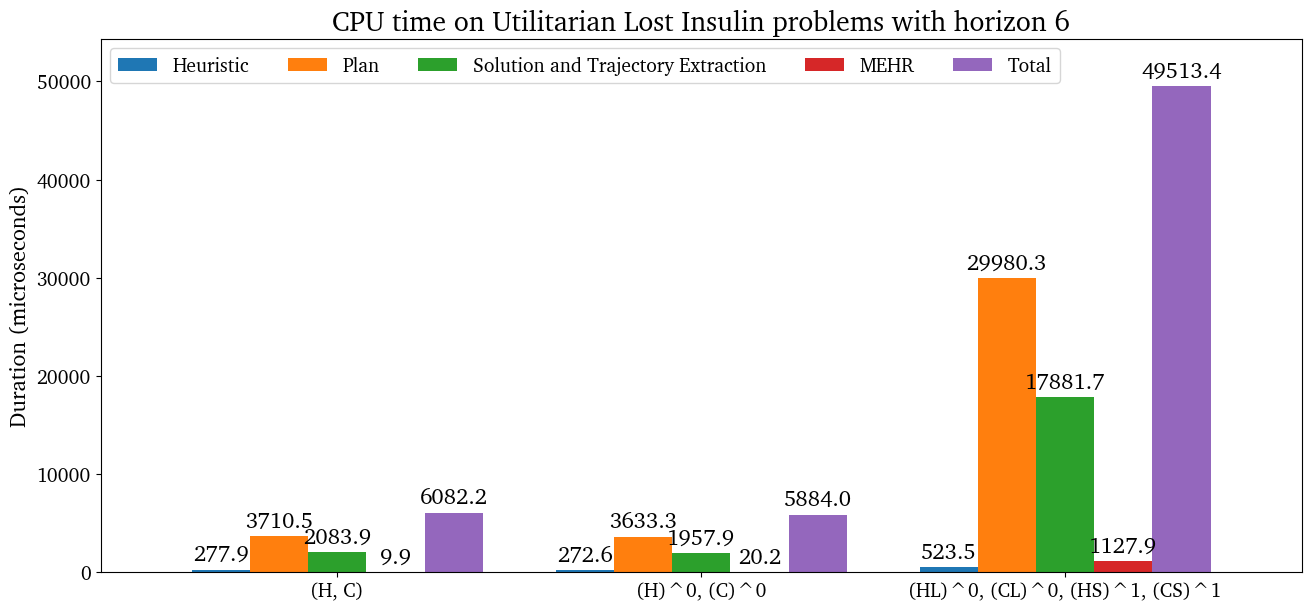

In [13]:
import re

configs_names = ["(Hal, Carla)", "(Hal)^0, (Carla)^0", "(HalLife)^0, (CarlaLife)^0, (HalSmall)^1, (CarlaSmall)^1"]

data = []
for c in configs_names:
    for env_rep in range(Environment_repetitions):
        # Assuming self.makePlanOutFileName exists
        outFile = er.makePlanOutFileName(c, 0, env_rep)
        with open(outFile, 'r') as file:
            json_data = json.load(file)
            data.append([c, env_rep, 
                            json_data["Duration_Heuristic"],
                            json_data["Duration_Plan"],
                            json_data["Duration_Sols"],
                            json_data["Duration_MEHR"],
                            json_data["Duration_Total"]])
time_df = pd.DataFrame(data, columns=["Config_name", "Env_rep", "Heuristic", "Plan", "Solution and Trajectory Extraction", "MEHR", "Total"])
time_df['Config_name'] = time_df['Config_name'].str.replace("HalLife", "HL")
time_df['Config_name'] = time_df['Config_name'].str.replace("CarlaLife", "CL")
time_df['Config_name'] = time_df['Config_name'].str.replace("HalSmall", "HS")
time_df['Config_name'] = time_df['Config_name'].str.replace("CarlaSmall", "CS")
time_df['Config_name'] = time_df['Config_name'].str.replace("Hal", "H")
time_df['Config_name'] = time_df['Config_name'].str.replace("Carla", "C")


time_categories = ['Heuristic', 'Plan', 'Solution and Trajectory Extraction', 'MEHR', 'Total']

averages = time_df.groupby('Config_name', sort=False)[time_categories].mean()

fig, ax = plt.subplots(layout='constrained', figsize=(13, 6))

averages.plot.bar(ax=ax, width=0.8, rot=0)

for container in ax.containers:
    formatted_label = re.sub(r"\^(\d)", r"$^{\1}$", str(container))
    ax.bar_label(container, padding=3, fmt='%.1f')
    
ax.set_ylabel('Duration (microseconds)')
ax.set_xlabel('')
ax.set_title('CPU time on Utilitarian Lost Insulin problems with horizon 6')

ax.legend(loc='upper left', ncols=5)
ax.set_ylim(0, time_df['Total'].max() * 1.05)

plt.savefig(f"{er.figuresFolder}/TimeGraph.png", dpi=300)

In [14]:
from matplotlib.ticker import MaxNLocator

plt.rcParams.update({
    "font.family": "Charter",
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})

dep_var = "Total"

# Make a copy of the whole dataframe, because you want every Config_name
df_ = df.copy()

# Ensure numeric values
df_[dep_var] = pd.to_numeric(df_[dep_var])
df_["Horizon"] = pd.to_numeric(df_["Horizon"])

fig, ax = plt.subplots(figsize=(10, 7))

linestyles = ["-", "--", "-.", ":"]
markers = ["o", "s", "^", "D", "x", "*"]


for i, config_name in enumerate(configs_names):
    group = df_[df_["Config_name"] == config_name].sort_values("Horizon")
    ax.plot(
        group["Horizon"],
        group[dep_var],
        marker=markers[i  % len(markers)],
        label=latex_config_name(config_name),
        alpha=0.75,
        linewidth=1.5,
        linestyle=linestyles[i % len(linestyles)]
    )

ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_title("Total CPU time vs Horizon")
ax.set_xlabel("Horizon")
ax.set_ylabel(f"Average total time CPU in microseconds")

ax.legend(loc="upper left")
fig.tight_layout()
plt.show()


KeyError: 'Total'